# NSD-Imagery data orientation

This notebook is a guided tour of the **minimal project download**. It is deliberately descriptive: the goal is to understand the files, dimensions, units, trial structure, and ROI labels before implementing RSA.

The central data relationship is:

`behavior/design → beta index → 3-D voxel response → ROI mask → trial × voxel matrix`

Memory rule: the HDF5 beta array stays on disk. We read selected voxels across events; we do **not** execute `h5['betas'][:]`.

## 0. Environment

No GPU, CUDA, PyTorch, FreeSurfer, or fMRI preprocessing package is needed for this notebook. The only less-standard dependencies are `h5py` (lazy HDF5 access) and `nibabel` (NIfTI/MGH files).

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'nsdimagery').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'nsdimagery').is_dir():
    raise RuntimeError('Start Jupyter from the repository root or its notebooks/ directory.')
sys.path.insert(0, str(REPO_ROOT))

import h5py
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image
from scipy.io import loadmat

from nsdimagery.io import (
    build_run_table, describe_hdf5, extract_masked_betas, find_data_root,
    infer_beta_layout, load_behavior, load_roi, paths_for_subject, read_ctab, validate_download,
)

sns.set_theme(style='whitegrid', context='notebook')
print('Python:', sys.version.split()[0])
print('Repository:', REPO_ROOT)

Python: 3.14.6
Repository: /home/jovyan/NHprojectNSDimagery


## 1. Locate and validate the download

Your expected root is `REPO/data/nsd`. The manifest checks all eight subjects, all three volumetric masks, all beta files, and the 12 behavioral TSVs per subject.

In [2]:
DATA_ROOT = find_data_root(REPO_ROOT)
print('Data root:', DATA_ROOT)

manifest = validate_download(DATA_ROOT)
display(manifest)
assert manifest['ok'].all(), 'At least one expected file is absent.'

print(f"Total size covered by manifest: {manifest['size_MiB'].sum()/1024:.2f} GiB")

Data root: /home/jovyan/NHprojectNSDimagery/data/nsd


,subject,kind,path,ok,size_MiB
0,subj01,beta,/home/jovyan/NHprojectNSDimagery/data/nsd/nsdd...,True,1003.736504
1,subj01,nsdgeneral,/home/jovyan/NHprojectNSDimagery/data/nsd/nsdd...,True,0.062101
2,subj01,prf-visualrois,/home/jovyan/NHprojectNSDimagery/data/nsd/nsdd...,True,0.062545
3,subj01,streams,/home/jovyan/NHprojectNSDimagery/data/nsd/nsdd...,True,0.064960
4,subj01,behavior TSVs (expected 12),/home/jovyan/NHprojectNSDimagery/data/nsd/nsdd...,True,0.080190
5,subj02,beta,/home/jovyan/NHprojectNSDimagery/data/nsd/nsdd...,True,1048.145256
6,subj02,nsdgeneral,/home/jovyan/NHprojectNSDimagery/data/nsd/nsdd...,True,0.061416
7,subj02,prf-visualrois,/home/jovyan/NHprojectNSDimagery/data/nsd/nsdd...,True,0.061799
8,subj02,streams,/home/jovyan/NHprojectNSDimagery/data/nsd/nsdd...,True,0.063682
9,subj02,behavior TSVs (expected 12),/home/jovyan/NHprojectNSDimagery/data/nsd/nsdd...,True,0.078645


Total size covered by manifest: 7.63 GiB


### What each top-level folder means

- `nsddata/experiments/nsdimagery`: task definitions, design matrices, cue pairs, and target images.
- `nsddata/bdata/nsdimagery`: what happened on each presented behavioral trial.
- `nsddata/ppdata/.../roi`: 3-D integer masks already aligned to each subject's 1.8-mm beta volume.
- `nsddata/freesurfer/.../label`: surface masks and color tables; in this project the color tables mainly tell us what the volumetric integer codes mean.
- `nsddata_betas`: the large estimated BOLD response amplitudes.

## 2. Experimental and beta-block structure

There are 12 acquired runs. Every run has 48 behavioral trials. Vision and imagery produce one beta per trial; attention produces two betas per trial (cue and detection epochs). Thus `9 × 48 + 3 × 96 = 720` beta volumes.

The table below gives safe **run-level** slices. We will not infer the within-attention event mapping until inspecting the GLMsingle design.

In [3]:
run_table = build_run_table()
display(run_table)
print('Behavioral trials:', run_table['n_behavior_trials'].sum())
print('Modeled beta events:', run_table['n_betas'].sum())

,run_number,run_name,task,stimulus_set,n_behavior_trials,n_betas,beta_start_python,beta_stop_python_exclusive,beta_first_human,beta_last_human
0,1,visA,vision,A,48,48,0,48,1,48
1,2,attA,attention,A,48,96,48,144,49,144
2,3,imgA_1,imagery,A,48,48,144,192,145,192
3,4,visB,vision,B,48,48,192,240,193,240
4,5,attB,attention,B,48,96,240,336,241,336
5,6,imgB_1,imagery,B,48,48,336,384,337,384
6,7,visC,vision,C,48,48,384,432,385,432
7,8,attC,attention,C,48,96,432,528,433,528
8,9,imgC_1,imagery,C,48,48,528,576,529,576
9,10,imgA_2,imagery,A,48,48,576,624,577,624


Behavioral trials: 576
Modeled beta events: 720


## 3. See the target stimuli

Set A contains six geometric patterns. Set B contains five NSD natural scenes and one artwork. Set C is conceptual (`stripes → zebra → mammal`, `yellow → banana → fruit`) and therefore has no single fixed raw target image per concept.

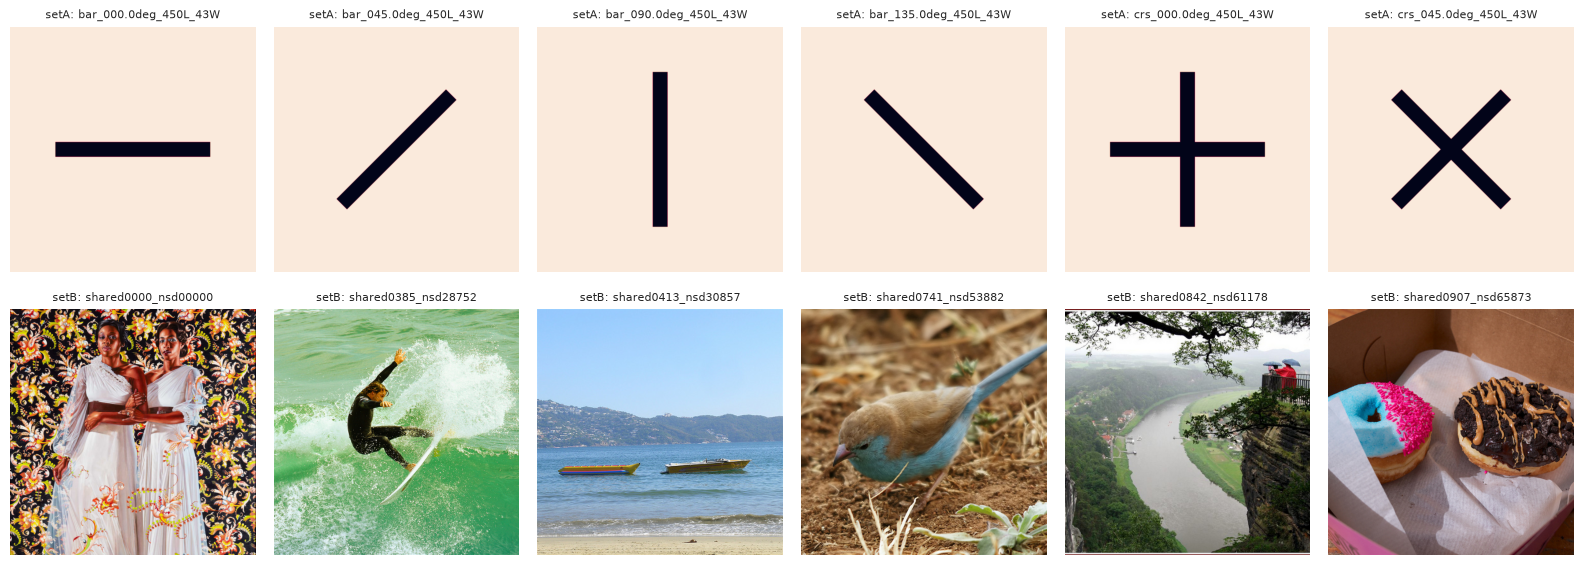

In [14]:
stim_root = DATA_ROOT / 'nsddata' / 'experiments' / 'nsdimagery' / 'rawtargetimages'
image_paths = sorted(stim_root.glob('set*/*.png'))

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for ax, path in zip(axes.flat, image_paths):
    ax.imshow(Image.open(path))
    ax.set_title(f'{path.parent.name}: {path.stem}', fontsize=8)
    ax.axis('off')
plt.tight_layout()

## 4. Behavioral TSVs: one row per presented trial

Important columns include `CONDITION` (what was seen/attended/imagined), `CUE`, `FRAMEFILE`, `GROUNDTRUTH`, `BUTTON`, and timing/RT fields. In imagery, button 1 means vivid and button 2 means not vivid.

In [5]:
SUBJECT = 1
behavior = load_behavior(DATA_ROOT, SUBJECT)
print('Shape:', behavior.shape)
print('Columns:')
print(list(behavior.columns))
display(behavior.head())

run_order = run_table['run_name'].tolist()
trial_counts = behavior.groupby('RUN_NAME').size().reindex(run_order)
display(trial_counts.rename('behavioral rows').to_frame())
assert (trial_counts == 48).all()

Shape: (576, 22)
Columns:
['SOURCE_FILE', 'RUN_NAME', 'SUBJECT', 'SESSION', 'RUN', 'TRIAL', 'CONDITION', 'CUE', 'FRAMEFILE', 'IMAGEFILE', 'GROUNDTRUTH', 'ISCORRECT', 'CHANGEMIND', 'TOTAL1', 'TOTAL2', 'BUTTON', 'TRIALONSET', 'TRIALEND', 'IMAGEONSET', 'IMAGESERIESENDS', 'FINALDECISIONTIME', 'RT']


,SOURCE_FILE,RUN_NAME,SUBJECT,SESSION,RUN,TRIAL,CONDITION,CUE,FRAMEFILE,IMAGEFILE,...,CHANGEMIND,TOTAL1,TOTAL2,BUTTON,TRIALONSET,TRIALEND,IMAGEONSET,IMAGESERIESENDS,FINALDECISIONTIME,RT
0,nsdimagery_subj01_attA.tsv,attA,1,1,2,1,V,V,blank00000_00000000_cueV.png,bar_090.0deg_450L_43W_cueX.png,...,0.0,0,1,2.0,16.014949,23.999315,19.876323,21.875733,22.478673,2602.349417
1,nsdimagery_subj01_attA.tsv,attA,1,1,2,2,P,P,blank00000_00000000_cueP.png,NaN,...,0.0,0,1,2.0,23.999315,32.000094,NaN,29.875334,30.473749,598.414658
2,nsdimagery_subj01_attA.tsv,attA,1,1,2,3,L,L,blank00000_00000000_cueL.png,NaN,...,0.0,1,0,1.0,32.000094,39.999688,NaN,37.875582,38.380416,504.833263
3,nsdimagery_subj01_attA.tsv,attA,1,1,2,4,R,R,blank00000_00000000_cueR.png,NaN,...,0.0,0,1,2.0,39.999688,48.000848,NaN,45.875317,46.406260,530.943276
4,nsdimagery_subj01_attA.tsv,attA,1,1,2,5,V,V,blank00000_00000000_cueV.png,NaN,...,0.0,0,1,2.0,48.000848,56.000142,NaN,53.874897,54.405354,530.456974


,behavioral rows
RUN_NAME,
visA,48
attA,48
imgA_1,48
visB,48
attB,48
imgB_1,48
visC,48
attC,48
imgC_1,48


,RUN_NAME,BUTTON_NUMERIC,n_trials
0,imgA_1,1.0,47
1,imgA_1,2.0,1
2,imgA_2,1.0,48
3,imgB_1,1.0,46
4,imgB_1,2.0,2
5,imgB_2,1.0,46
6,imgB_2,2.0,2
7,imgC_1,1.0,47
8,imgC_1,NaN,1
9,imgC_2,1.0,48


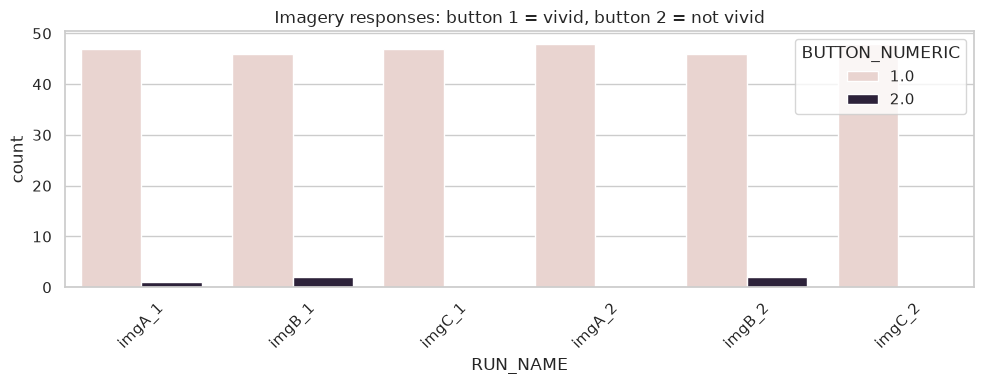

In [6]:
imagery = behavior[behavior['RUN_NAME'].str.startswith('img')].copy()
imagery['BUTTON_NUMERIC'] = pd.to_numeric(imagery['BUTTON'], errors='coerce')
vividness = (
    imagery.groupby('RUN_NAME')['BUTTON_NUMERIC']
    .value_counts(dropna=False)
    .rename('n_trials')
    .reset_index()
)
display(vividness)

fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(data=imagery, x='RUN_NAME', hue='BUTTON_NUMERIC', order=[r for r in run_order if r.startswith('img')], ax=ax)
ax.set_title('Imagery responses: button 1 = vivid, button 2 = not vivid')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

## 5. MATLAB design files

The run-level `*_dm.mat` files describe conditions over time. `designmatrixGLMsingle.mat` is the design actually used to obtain the 720 single-event betas. This cell inventories keys and shapes without presuming their internal organization.

In [7]:
experiment_dir = DATA_ROOT / 'nsddata' / 'experiments' / 'nsdimagery'

def mat_inventory(path):
    try:
        contents = loadmat(path, squeeze_me=True, struct_as_record=False)
        return pd.DataFrame([
            {'key': key, 'type': type(value).__name__, 'shape': getattr(value, 'shape', None)}
            for key, value in contents.items() if not key.startswith('__')
        ])
    except NotImplementedError:
        return describe_hdf5(path).rename(columns={'name': 'key'})

for filename in ['visA_dm.mat', 'imgA_1_dm.mat', 'designmatrixGLMsingle.mat']:
    print('\n', filename)
    display(mat_inventory(experiment_dir / filename))


 visA_dm.mat


,key,type,shape
0,condit_list,ndarray,"(12, 2)"
1,dm,ndarray,"(240, 12)"



 imgA_1_dm.mat


,key,type,shape
0,condit_list,ndarray,"(6,)"
1,dm,ndarray,"(240, 6)"



 designmatrixGLMsingle.mat


,key,type,shape
0,stimulus,ndarray,"(12,)"


## 6. HDF5 beta file: shape, chunks, and units

The manual describes `/betas` in MATLAB order as `X × Y × Z × 720`. Because these files were written from MATLAB, **h5py exposes this release as `720 × Z × Y × X`**. For example, subject 1 has beta shape `(720, 83, 104, 81)` but NIfTI mask shape `(81, 104, 83)`. Thus a NIfTI coordinate `(x, y, z)` indexes HDF5 as `betas[:, z, y, x]`. The code detects this layout rather than assuming axes. Values are stored as `int16` after multiplying percent signal change by 300; correct loading casts to floating point and divides by 300.

In [8]:
subject_paths = paths_for_subject(DATA_ROOT, SUBJECT)
display(describe_hdf5(subject_paths['beta']))

with h5py.File(subject_paths['beta'], 'r') as handle:
    beta_dataset = handle['betas']
    beta_shape = beta_dataset.shape
    print('Shape:', beta_shape)
    print('dtype:', beta_dataset.dtype)
    print('chunks:', beta_dataset.chunks)
    print('The event axis is the dimension of length 720; ROI shape verification comes next.')
    assert 720 in beta_shape

,name,shape,dtype,chunks,compression
0,/betas,"(720, 83, 104, 81)",int16,"(720, 1, 1, 1)",None


Shape: (720, 83, 104, 81)
dtype: int16
chunks: (720, 1, 1, 1)
The event axis is the dimension of length 720; ROI shape verification comes next.


## 7. Volumetric ROI masks and label tables

All three masks live in the same subject-native `func1pt8mm` grid as the beta data. `nsdgeneral` is binary. The other masks contain integer codes; the `.ctab` files translate codes into anatomical names. Values 0 (and sometimes −1) are not selected cortical ROIs.

In [9]:
roi_arrays = {}
for roi_name in ['nsdgeneral', 'prf-visualrois', 'streams']:
    array, image = load_roi(DATA_ROOT, SUBJECT, roi_name)
    roi_arrays[roi_name] = array
    values, counts = np.unique(array, return_counts=True)
    summary = pd.DataFrame({'label': values, 'n_voxels': counts})
    print(f'\n{roi_name}: shape={array.shape}, voxel sizes={image.header.get_zooms()[:3]}')
    display(summary[summary['label'] > 0])
    layout = infer_beta_layout(beta_shape, array.shape)
    print('h5py layout:', layout)

prf_ctab = read_ctab(subject_paths['labels'] / 'prf-visualrois.mgz.ctab')
streams_ctab = read_ctab(subject_paths['labels'] / 'streams.mgz.ctab')
print('pRF visual ROI labels')
display(prf_ctab)
print('Streams labels')
display(streams_ctab)


nsdgeneral: shape=(81, 104, 83), voxel sizes=(np.float32(1.8), np.float32(1.8), np.float32(1.8))


,label,n_voxels
2,1,15724


h5py layout: events_first_zyx

prf-visualrois: shape=(81, 104, 83), voxel sizes=(np.float32(1.8), np.float32(1.8), np.float32(1.8))


,label,n_voxels
2,1,594
3,2,756
4,3,834
5,4,599
6,5,646
7,6,541
8,7,687


h5py layout: events_first_zyx

streams: shape=(81, 104, 83), voxel sizes=(np.float32(1.8), np.float32(1.8), np.float32(1.8))


,label,n_voxels
2,1,5917
3,2,986
4,3,834
5,4,950
6,5,7604
7,6,7799
8,7,3548


h5py layout: events_first_zyx
pRF visual ROI labels


,label,name
0,0,Unknown
1,1,V1v
2,2,V1d
3,3,V2v
4,4,V2d
5,5,V3v
6,6,V3d
7,7,hV4


Streams labels


,label,name
0,0,Unknown
1,1,early
2,2,midventral
3,3,midlateral
4,4,midparietal
5,5,ventral
6,6,lateral
7,7,parietal


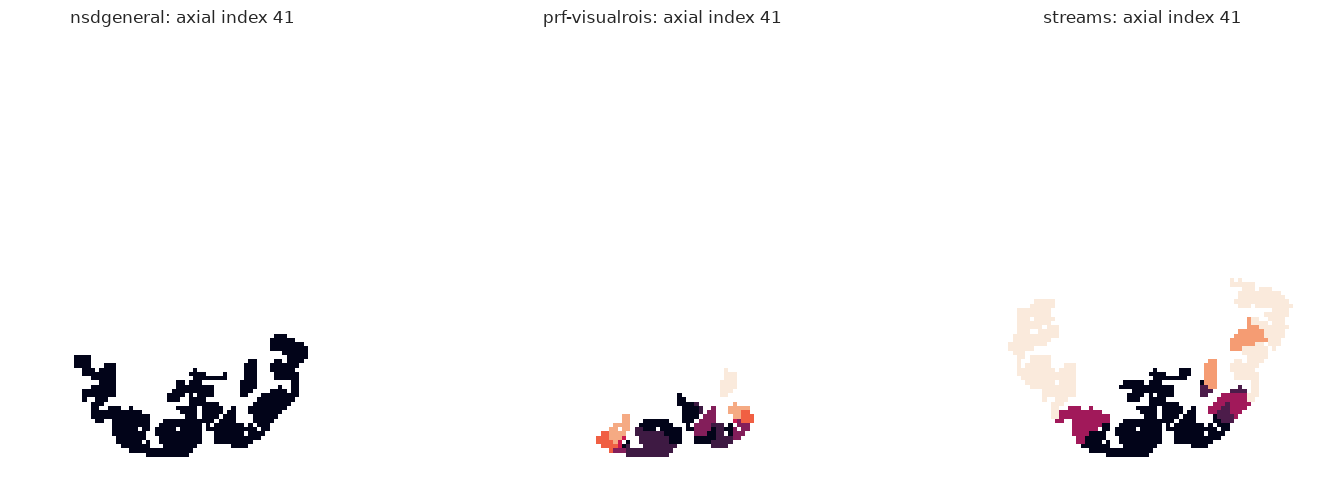

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, array) in zip(axes, roi_arrays.items()):
    z = array.shape[2] // 2
    shown = np.where(array[:, :, z] > 0, array[:, :, z], np.nan)
    ax.imshow(np.rot90(shown), interpolation='nearest')
    ax.set_title(f'{name}: axial index {z}')
    ax.axis('off')
plt.tight_layout()

## 8. Safely read a small voxel sample

For orientation, sample 300 `nsdgeneral` voxels and read all 720 events. The resulting matrix is `events × voxels`. This is tiny compared with the full four-dimensional array and already supports diagnostic plots and a toy RDM.

events × sampled voxels: (720, 300)
Units: percent signal change
count    216000.000000
mean          0.675599
std           1.908866
min         -18.170000
1%           -2.916700
10%          -1.056667
50%           0.440000
90%           2.590000
99%           6.980033
max          38.480000
dtype: float64


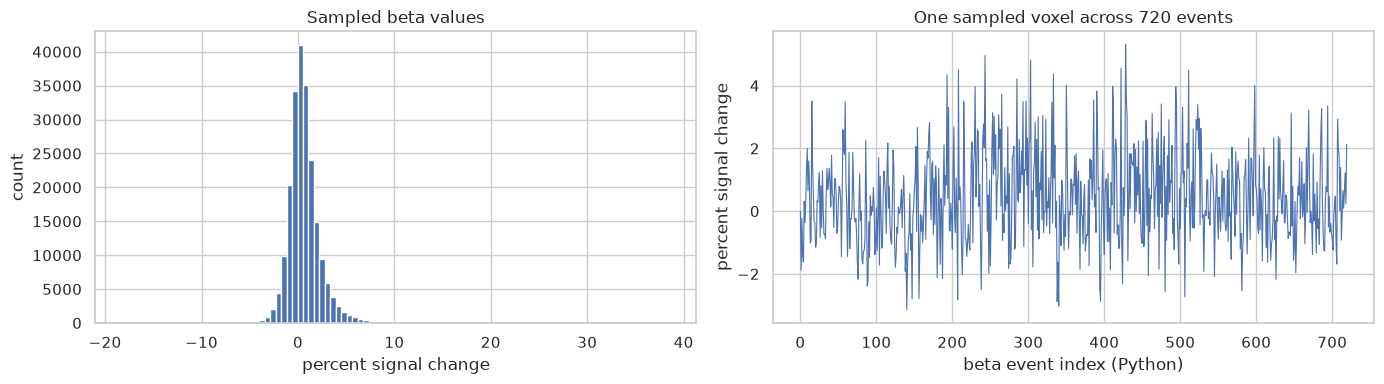

In [11]:
sample_betas, voxel_coordinates = extract_masked_betas(
    subject_paths['beta'], roi_arrays['nsdgeneral'], max_voxels=300, seed=2026
)
print('events × sampled voxels:', sample_betas.shape)
print('Units: percent signal change')
print(pd.Series(sample_betas.ravel()).describe(percentiles=[.01, .1, .5, .9, .99]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(sample_betas.ravel(), bins=100)
axes[0].set(xlabel='percent signal change', ylabel='count', title='Sampled beta values')
axes[1].plot(sample_betas[:, 0], linewidth=0.8)
axes[1].set(xlabel='beta event index (Python)', ylabel='percent signal change', title='One sampled voxel across 720 events')
plt.tight_layout()

,run_name,task,stimulus_set,mean_beta,mean_absolute_beta,spatial_sd
0,visA,vision,A,0.395089,1.053106,1.382648
1,attA,attention,A,0.731752,1.259802,1.627470
2,imgA_1,imagery,A,0.346055,0.991844,1.287636
3,visB,vision,B,0.626013,1.328161,1.801985
4,attB,attention,B,1.160481,1.687249,2.265841
5,imgB_1,imagery,B,0.431551,1.052254,1.386377
6,visC,vision,C,0.785438,1.514047,2.135977
7,attC,attention,C,1.110064,1.575621,2.213084
8,imgC_1,imagery,C,0.463017,1.092209,1.425256
9,imgA_2,imagery,A,0.344668,1.105423,1.482620


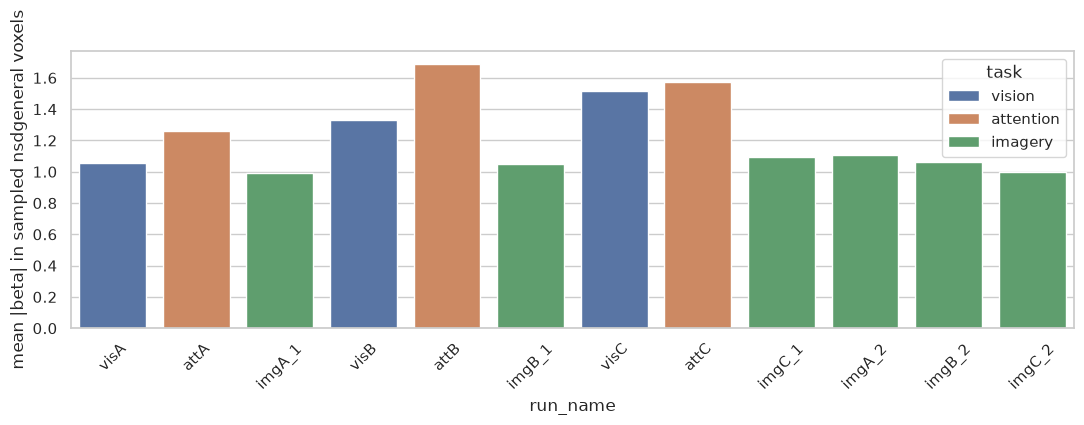

In [12]:
run_summaries = []
for row in run_table.itertuples(index=False):
    block = sample_betas[row.beta_start_python:row.beta_stop_python_exclusive]
    run_summaries.append({
        'run_name': row.run_name,
        'task': row.task,
        'stimulus_set': row.stimulus_set,
        'mean_beta': float(block.mean()),
        'mean_absolute_beta': float(np.abs(block).mean()),
        'spatial_sd': float(block.std(axis=1).mean()),
    })
run_summaries = pd.DataFrame(run_summaries)
display(run_summaries)

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(data=run_summaries, x='run_name', y='mean_absolute_beta', hue='task', dodge=False, ax=ax)
ax.set_ylabel('mean |beta| in sampled nsdgeneral voxels')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

## 9. What you should now understand

1. A behavioral row describes a presented trial; a beta volume describes a modeled event. They are not globally one-to-one because attention has two modeled epochs.
2. Every beta is a three-dimensional response-amplitude map in subject-native 1.8-mm space.
3. The raw stored integer must be divided by 300 to recover percent signal change.
4. ROI masks select interpretable voxel subsets without registration because their spatial shapes match the beta grid.
5. Set A and set B give the cleanest first vision-versus-imagery comparison. Set C requires special care because concepts are paired with varying concrete images in vision.

### Next notebook

The next step should construct a verified event table for vision and imagery, average repeated beta patterns by subject × condition × target × ROI, and compute the first neural RDM. Do not begin CLIP/HOG feature extraction until that table passes alignment checks.